Question 10


/tmp/ipython-input-141631910.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks + [market], start=start, end=end, interval="1d")
[*********************100%***********************]  8 of 8 completed


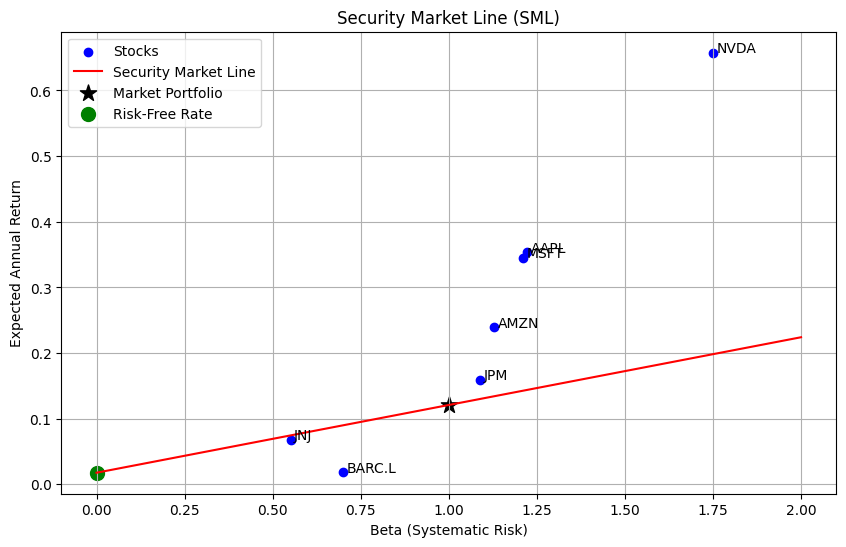


Estimated Betas and Annualized Returns:



,Stock,Beta,Return
0,AAPL,1.221826,0.353501
1,MSFT,1.211061,0.345246
2,NVDA,1.749493,0.657454
3,AMZN,1.128220,0.238972
4,JPM,1.088221,0.159515
5,BARC.L,0.701042,0.018346
6,JNJ,0.551014,0.068045


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas_datareader.data as web
import datetime as dt
import yfinance as yf

# Defining Tickers
stocks = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'JPM', 'BARC.L', 'JNJ']
market = '^GSPC'  # S&P 500
start = '2018-01-01'
end = '2024-01-01'

# Download stock and market data
data = yf.download(stocks + [market], start=start, end=end, interval="1d")

# Handle MultiIndex returned by yfinance
if isinstance(data.columns, pd.MultiIndex):
    if "Adj Close" in data.columns.levels[1]:
        prices = data["Adj Close"]
    else:
        prices = data["Close"]
else:
    prices = data["Close"] if "Close" in data.columns else data

# Fix missing values then compute daily returns
prices = prices.ffill().bfill()
returns = prices.pct_change().dropna()

# Download 4-week Treasury Bill rate (risk-free rate) from FRED
rf_data = web.DataReader('TB4WK', 'fred', start, end)
rf_data = rf_data.dropna().rename(columns={'TB4WK': 'RiskFree'})

# Convert annualized percentage to daily decimal rate
rf_data['Daily_RF'] = ((1 + rf_data['RiskFree'] / 100) ** (1 / 252)) - 1

# Align with returns data for the same dates
rf_data = rf_data.reindex(returns.index).ffill()
rf = rf_data['Daily_RF']

# Excess market return
excess_market = returns[market] - rf

# Annualized risk-free rate
annual_rf = rf.mean() * 252

# Calculate beta and expected return for each stock
results = []

for stock in stocks:
    excess_stock = returns[stock] - rf

    # Combine stock & market return before regression
    X = sm.add_constant(excess_market)
    df_reg = pd.concat([excess_stock, X], axis=1).dropna()

    y = df_reg.iloc[:, 0]
    X_clean = df_reg.iloc[:, 1:]

    model = sm.OLS(y, X_clean).fit()

    # Extract beta
    beta = model.params.iloc[1]
    alpha = model.params.iloc[0]

    # Annualize actual average return
    avg_annual_return = (1 + returns[stock].mean())**252 - 1

    results.append({'Stock': stock, 'Beta': beta, 'Return': avg_annual_return})

results_df = pd.DataFrame(results)

# Plot Security Market Line (SML)
plt.figure(figsize=(10,6))

# Plot stocks
plt.scatter(results_df['Beta'], results_df['Return'], color='blue', label='Stocks')

# Adding labels
for i in range(len(results_df)):
    plt.text(results_df['Beta'][i] + 0.01, results_df['Return'][i], results_df['Stock'][i])

# Diagram
market_return = (1 + returns[market].mean())**252 - 1
beta_range = np.linspace(0, 2, 50)
sml = annual_rf + beta_range * (market_return - annual_rf)

plt.plot(beta_range, sml, color='red', label='Security Market Line')
plt.scatter(1, market_return, color='black', marker='*', s=150, label='Market Portfolio')
plt.scatter(0, annual_rf, color='green', marker='o', s=100, label='Risk-Free Rate')

# Formatting
plt.title('Security Market Line (SML)')
plt.xlabel('Beta (Systematic Risk)')
plt.ylabel('Expected Annual Return')
plt.grid(True)
plt.legend()
plt.show()

# Results
print("\nEstimated Betas and Annualized Returns:\n")
display(results_df)


Question 12

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf

# Date range
start = "2024-09-01"
end = "2025-09-01"

# Best and worst stocks identified from Q10
tickers = ["NVDA", "BARC.L"]

# Download daily prices
prices = yf.download(tickers, start=start, end=end, interval="1d")["Close"]

# Handle missing days (holidays, weekends)
prices = prices.ffill().bfill()

# Compute daily returns
returns = prices.pct_change().dropna()

# Quick check
returns.head()


/tmp/ipython-input-2620236720.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start, end=end, interval="1d")["Close"]
[*********************100%***********************]  2 of 2 completed


Ticker,BARC.L,NVDA
Date,,
2024-09-03,-0.018050,0.000000
2024-09-04,0.002914,-0.016574
2024-09-05,0.021681,0.009415
2024-09-06,-0.033691,-0.040854
2024-09-09,0.014263,0.035398


In [5]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Summary for NVDA
                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                 1234
Model:                 ARIMA(4, 1, 1)   Log Likelihood                2495.463
Date:                Mon, 15 Dec 2025   AIC                          -4978.926
Time:                        19:48:16   BIC                          -4948.223
Sample:                             0   HQIC                         -4967.376
                               - 1234                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1025      0.020     -5.081      0.000      -0.142      -0.063
ar.L2          0.0268      0.023      1.166      0.243      -0.018       0.072
ar.L3          0.0063      0.

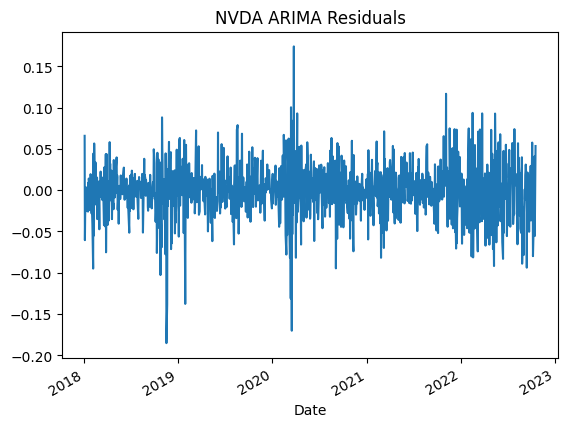

NVDA 1-day return forecast: -0.009019375473725916
NVDA 7-day return forecast:
1234   -0.009019
1235    0.000139
1236   -0.001043
1237   -0.002077
1238   -0.001396
1239   -0.001575
1240   -0.001535
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [13]:
# ARIMA model for NVDA
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
import matplotlib.pyplot as plt

# Select NVDA returns
series = returns["NVDA"]

# Test split (80% train, 20% test)
split = int(len(series) * 0.8)
train = series.iloc[:split]
test = series.iloc[split:]

# Step 1: Auto-select ARIMA order
auto_model = auto_arima(
    train,
    start_p=0, d=1, start_q=0,
    max_p=5, max_d=5, max_q=5,
    seasonal=False,
    trace=False
)

# Step 2: Fit ARIMA model
order = auto_model.order
arima_model = ARIMA(train, order=order).fit()

# Step 3: Inspect model
print("ARIMA Summary for NVDA")
print(arima_model.summary())

# Plot residuals
arima_model.resid.plot(title="NVDA ARIMA Residuals")
plt.show()

# Step 4: Forecast returns
forecast_1 = arima_model.get_forecast(steps=1)
forecast_7 = arima_model.get_forecast(steps=7)

print("NVDA 1-day return forecast:", forecast_1.predicted_mean.values[0])
print("NVDA 7-day return forecast:")
print(forecast_7.predicted_mean)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Summary for BARC.L
                               SARIMAX Results                                
Dep. Variable:                 BARC.L   No. Observations:                  204
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 487.599
Date:                Mon, 15 Dec 2025   AIC                           -971.198
Time:                        18:31:20   BIC                           -964.572
Sample:                             0   HQIC                          -968.518
                                - 204                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9999      2.585     -0.387      0.699      -6.066       4.066
sigma2         0.0005      0.001      0.388      0.698      -0.002       0.003
Ljung-Box (L1) (Q):        

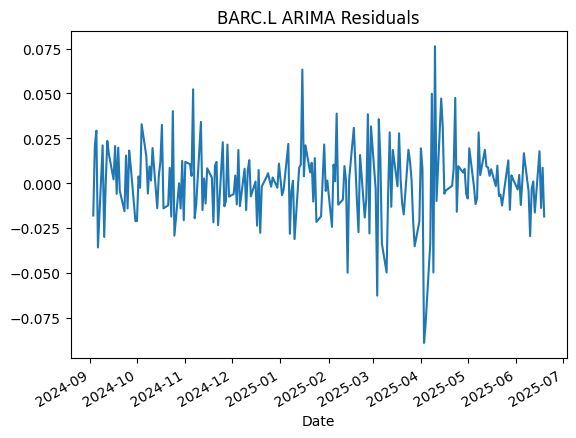

BARC.L 1-day return forecast: 0.0019118002494979483
BARC.L 7-day return forecast:
204    0.001912
205    0.001912
206    0.001912
207    0.001912
208    0.001912
209    0.001912
210    0.001912
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [7]:
# STEP 4: ARIMA model for BARC.L

from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
import matplotlib.pyplot as plt

# Select BARC.L returns
series = returns["BARC.L"]

# Train-test split (80% train, 20% test)
split = int(len(series) * 0.8)
train = series.iloc[:split]
test = series.iloc[split:]

# Step 1: Auto-select ARIMA order (seminar style)
auto_model = auto_arima(
    train,
    start_p=0, d=1, start_q=0,
    max_p=5, max_d=5, max_q=5,
    seasonal=False,
    trace=False
)

# Step 2: Fit ARIMA model
order = auto_model.order
arima_model = ARIMA(train, order=order).fit()

# Step 3: Inspect model
print("ARIMA Summary for BARC.L")
print(arima_model.summary())

# Plot residuals
arima_model.resid.plot(title="BARC.L ARIMA Residuals")
plt.show()

# Step 4: Forecast returns
forecast_1 = arima_model.get_forecast(steps=1)
forecast_7 = arima_model.get_forecast(steps=7)

print("BARC.L 1-day return forecast:", forecast_1.predicted_mean.values[0])
print("BARC.L 7-day return forecast:")
print(forecast_7.predicted_mean)


In [9]:
!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.1 MB/s eta 0:00:00


Iteration:      5,   Func. Count:     33,   Neg. LLF: 635.6041446933175
Optimization terminated successfully    (Exit mode 0)
            Current function value: 635.6041288885517
            Iterations: 7
            Function evaluations: 43
            Gradient evaluations: 7
GARCH(1,1) Summary for NVDA
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   NVDA   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -635.604
Distribution:                  Normal   AIC:                           1279.21
Method:            Maximum Likelihood   BIC:                           1293.37
                                        No. Observations:                  255
Date:                Mon, Dec 15 2025   Df Residuals:                      254
Time:                        18:40:02   Df Model:            

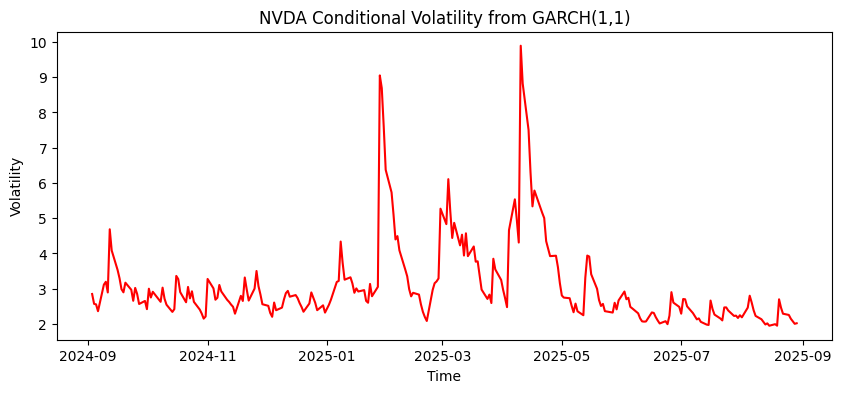

In [10]:
# STEP 5: GARCH(1,1) model for NVDA

from arch import arch_model
import matplotlib.pyplot as plt

# GARCH requires returns in percentage form
garch_returns = returns["NVDA"] * 100

# Fit GARCH(1,1)
garch11_model = arch_model(
    garch_returns,
    vol='GARCH',
    p=1,
    o=0,
    q=1,
    dist='normal'
)

garch11_fit = garch11_model.fit(update_freq=5)

# Model summary
print("GARCH(1,1) Summary for NVDA")
print(garch11_fit.summary())

# Plot conditional volatility
plt.figure(figsize=(10,4))
plt.plot(garch11_fit.conditional_volatility, color='red')
plt.title("NVDA Conditional Volatility from GARCH(1,1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()


Iteration:      5,   Func. Count:     34,   Neg. LLF: 524.311499094867
Optimization terminated successfully    (Exit mode 0)
            Current function value: 524.3111583216548
            Iterations: 9
            Function evaluations: 53
            Gradient evaluations: 9
GARCH(1,1) Summary for BARC.L
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 BARC.L   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -524.311
Distribution:                  Normal   AIC:                           1056.62
Method:            Maximum Likelihood   BIC:                           1070.79
                                        No. Observations:                  255
Date:                Mon, Dec 15 2025   Df Residuals:                      254
Time:                        18:51:32   Df Model:           

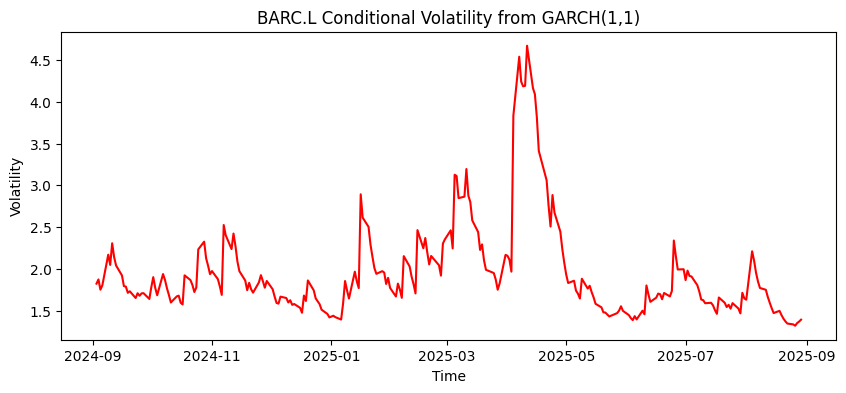

In [11]:
# STEP 6: GARCH(1,1) model for BARC.L

from arch import arch_model
import matplotlib.pyplot as plt

# GARCH requires returns in percentage form
garch_returns = returns["BARC.L"] * 100

# Fit GARCH(1,1)
garch11_model = arch_model(
    garch_returns,
    vol='GARCH',
    p=1,
    o=0,
    q=1,
    dist='normal'
)

garch11_fit = garch11_model.fit(update_freq=5)

# Model summary
print("GARCH(1,1) Summary for BARC.L")
print(garch11_fit.summary())

# Plot conditional volatility
plt.figure(figsize=(10,4))
plt.plot(garch11_fit.conditional_volatility, color='red')
plt.title("BARC.L Conditional Volatility from GARCH(1,1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()
